In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from matplotlib.animation import FuncAnimation
import matplotlib.colors as colors
from pathlib import Path


def simulate_paper_stack_wave(
    hp,
    N_layers=100,
    ha=0.015e-3,
    rho_p=800,
    rho_a=1.2,
    A=1e-4,
    E_p=1e7,
    hp_ref=0.1e-3,
    E_a_ref=2100,
    n_air=1.5,
    eta_p=10,
    eta_a=0.5,
    F0=0.01,
    tc=3e-3,
    T=0.03,
    n_time=3000,
    method="Radau",
    rtol=1e-6,
    atol=1e-9,
):
    """
    Simulate a 1D compression wave through a layered viscoelastic paper stack.

    Returns a dictionary containing the numerical wave function psi(x,t).
    """

    E_a = E_a_ref * (hp / hp_ref) ** n_air

    thickness = []
    rho = []
    E = []
    eta = []

    for _ in range(N_layers):
        thickness.append(hp)
        rho.append(rho_p)
        E.append(E_p)
        eta.append(eta_p)

        thickness.append(ha)
        rho.append(rho_a)
        E.append(E_a)
        eta.append(eta_a)

    thickness = np.array(thickness)
    rho = np.array(rho)
    E = np.array(E)
    eta = np.array(eta)

    N = len(thickness)
    h_total = np.sum(thickness)

    x = np.zeros(N + 1)
    x[1:] = np.cumsum(thickness)
    x_norm = x / h_total

    m = np.zeros(N + 1)

    for i in range(N):
        layer_mass = rho[i] * A * thickness[i]
        m[i] += 0.5 * layer_mass
        m[i + 1] += 0.5 * layer_mass

    k = E * A / thickness
    b = eta * A / thickness

    def impact_force(t):
        if 0 <= t <= tc:
            return F0 * np.sin(np.pi * t / tc)
        return 0.0

    def rhs(t, y):
        u = y[:N + 1].copy()
        v = y[N + 1:].copy()

        # Hard bottom boundary
        u[-1] = 0.0
        v[-1] = 0.0

        F = np.zeros(N + 1)

        for i in range(N):
            du = u[i + 1] - u[i]
            dv = v[i + 1] - v[i]

            force = k[i] * du + b[i] * dv

            F[i] += force
            F[i + 1] -= force

        F[0] += impact_force(t)

        a = F / m

        # Keep bottom node fixed
        a[-1] = 0.0
        v[-1] = 0.0

        return np.concatenate([v, a])

    y0 = np.zeros(2 * (N + 1))
    t_eval = np.linspace(0, T, n_time)

    sol = solve_ivp(
        rhs,
        t_span=(0, T),
        y0=y0,
        t_eval=t_eval,
        method=method,
        rtol=rtol,
        atol=atol,
    )

    if not sol.success:
        print("Solver warning:")
        print(sol.message)

    time = sol.t
    psi = sol.y[:N + 1, :]
    psi[-1, :] = 0.0

    top_signal = psi[0, :]
    near_bottom_signal = psi[-2, :]

    threshold_top = 0.05 * np.max(np.abs(top_signal))
    threshold_bottom = 0.05 * np.max(np.abs(near_bottom_signal))

    top_indices = np.where(np.abs(top_signal) > threshold_top)[0]
    bottom_indices = np.where(np.abs(near_bottom_signal) > threshold_bottom)[0]

    if len(top_indices) > 0 and len(bottom_indices) > 0:
        t_top = time[top_indices[0]]
        t_bottom = time[bottom_indices[0]]
        dt_arrival = t_bottom - t_top
        c_est = h_total / dt_arrival if dt_arrival > 0 else np.nan
    else:
        t_top = np.nan
        t_bottom = np.nan
        dt_arrival = np.nan
        c_est = np.nan

    return {
        "hp": hp,
        "ha": ha,
        "N_layers": N_layers,
        "N": N,
        "h_total": h_total,
        "time": time,
        "x": x,
        "x_norm": x_norm,
        "psi": psi,
        "top_signal": top_signal,
        "near_bottom_signal": near_bottom_signal,
        "thickness": thickness,
        "rho": rho,
        "E": E,
        "eta": eta,
        "E_a": E_a,
        "E_p": E_p,
        "eta_p": eta_p,
        "eta_a": eta_a,
        "F0": F0,
        "tc": tc,
        "t_top": t_top,
        "t_bottom": t_bottom,
        "dt_arrival": dt_arrival,
        "c_est": c_est,
    }


def print_summary(result):
    hp_mm = result["hp"] * 1000

    print(f"Paper thickness:       {hp_mm:.3f} mm")
    print(f"Total stack height:    {result['h_total'] * 1000:.3f} mm")
    print(f"Top arrival time:      {result['t_top'] * 1000:.3f} ms")
    print(f"Bottom arrival time:   {result['t_bottom'] * 1000:.3f} ms")
    print(f"Estimated wave speed:  {result['c_est']:.2f} m/s")
    print(f"Effective air stiffness E_a: {result['E_a']:.1f} Pa")


def save_wave_plots(
    result,
    output_dir="outputs",
    plot_times_ms=None,
):
    """
    Save:
    1. top/bottom signal plot
    2. wave profile plot
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    hp_mm = result["hp"] * 1000
    time = result["time"]
    x_norm = result["x_norm"]
    psi = result["psi"]

    if plot_times_ms is None:
        plot_times_ms = [0.5, 1, 2, 3, 5, 8, 12, 20]

    # Signal plot
    fig, ax = plt.subplots()

    ax.plot(time * 1000, result["top_signal"] * 1e6, label="top, x = 0")
    ax.plot(time * 1000, result["near_bottom_signal"] * 1e6, label="near bottom")

    ax.set_xlabel("time [ms]")
    ax.set_ylabel("displacement [µm]")
    ax.set_title(f"Compression wave through paper stack, hp = {hp_mm:.3f} mm")
    ax.legend()
    ax.grid(True)

    signal_path = output_dir / f"signals_hp_{hp_mm:.3f}mm.png"
    fig.savefig(signal_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    # Wave profiles
    fig, ax = plt.subplots()

    for t_ms in plot_times_ms:
        idx = np.argmin(np.abs(time - t_ms * 1e-3))
        ax.plot(x_norm, psi[:, idx] * 1e6, label=f"{time[idx] * 1000:.1f} ms")

    ax.set_xlabel("normalized position x")
    ax.set_ylabel(r"$\psi(x,t)$ [µm]")
    ax.set_title(f"Wave profile through stack, hp = {hp_mm:.3f} mm")
    ax.legend()
    ax.grid(True)

    profile_path = output_dir / f"wave_profiles_hp_{hp_mm:.3f}mm.png"
    fig.savefig(profile_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    return signal_path, profile_path


def save_wave_line_animation(
    result,
    output_dir="outputs",
    filename=None,
    n_animation_frames=300,
    fps=30,
):
    """
    Save a simple psi(x,t) line animation.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    hp_mm = result["hp"] * 1000
    time = result["time"]
    x_norm = result["x_norm"]
    psi = result["psi"]

    if filename is None:
        filename = f"wave_line_hp_{hp_mm:.3f}mm.gif"

    output_path = output_dir / filename

    fig, ax = plt.subplots()

    line, = ax.plot(x_norm, psi[:, 0] * 1e6)

    ax.set_xlabel("normalized position x")
    ax.set_ylabel(r"$\psi(x,t)$ [µm]")
    ax.set_title(f"Compression wave, hp = {hp_mm:.3f} mm")

    ylim = np.max(np.abs(psi)) * 1e6
    if ylim == 0:
        ylim = 1

    ax.set_ylim(-ylim, ylim)
    ax.grid(True)

    time_text = ax.text(
        0.02,
        0.95,
        "",
        transform=ax.transAxes,
        verticalalignment="top",
    )

    frame_indices = np.linspace(0, len(time) - 1, n_animation_frames).astype(int)

    def update(frame_number):
        idx = frame_indices[frame_number]
        line.set_ydata(psi[:, idx] * 1e6)
        time_text.set_text(f"t = {time[idx] * 1000:.2f} ms")
        return line, time_text

    ani = FuncAnimation(
        fig,
        update,
        frames=len(frame_indices),
        interval=1000 / fps,
        blit=True,
    )

    ani.save(output_path, writer="pillow", fps=fps)
    plt.close(fig)

    return output_path


def save_paper_lines_animation(
    result,
    output_dir="outputs",
    filename=None,
    motion_scale=20,
    n_width=80,
    n_animation_frames=300,
    fps=30,
    cmap_name="coolwarm",
):
    """
    Save an animation of the paper sheets as horizontal lines with fixed sides.
    This is slower than the simple psi(x,t) animation.
    """

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    hp_mm = result["hp"] * 1000
    time = result["time"]
    x = result["x"]
    psi = result["psi"]
    N = result["N"]
    h_total = result["h_total"]

    if filename is None:
        filename = f"paper_lines_hp_{hp_mm:.3f}mm.gif"

    output_path = output_dir / filename

    is_paper = np.zeros(N, dtype=bool)
    is_paper[0::2] = True
    paper_indices = np.where(is_paper)[0]

    s = np.linspace(0, 1, n_width)

    # Fixed sides, maximum motion in the middle
    shape = np.sin(np.pi * s)

    fig, ax = plt.subplots(figsize=(6, 8))

    ax.set_xlim(0, 1)
    ax.set_ylim(h_total * 1000, -2)
    ax.set_xlabel("schematic width")
    ax.set_ylabel("height in stack [mm]")
    ax.set_title(f"Moving paper sheets, hp = {hp_mm:.3f} mm")
    ax.set_facecolor("white")

    max_u = np.percentile(np.abs(psi), 99)
    if max_u == 0:
        max_u = 1e-12

    norm = colors.TwoSlopeNorm(vmin=-max_u, vcenter=0, vmax=max_u)
    cmap = plt.get_cmap(cmap_name)

    lines = []

    for i in paper_indices:
        y0 = x[i] * 1000

        line = ax.plot(
            s,
            np.full_like(s, y0),
            linewidth=1.4,
            color="gray",
        )[0]

        lines.append((line, i))

    time_text = ax.text(
        0.03,
        0.03,
        "",
        transform=ax.transAxes,
        bbox=dict(facecolor="white", alpha=0.8),
    )

    frame_indices = np.linspace(0, len(time) - 1, n_animation_frames).astype(int)

    def update_paper_lines(frame_number):
        idx = frame_indices[frame_number]

        for line, i in lines:
            u_mid = 0.5 * (psi[i, idx] + psi[i + 1, idx])
            y0 = x[i] * 1000

            y = y0 + motion_scale * u_mid * 1000 * shape

            line.set_ydata(y)
            line.set_color(cmap(norm(u_mid)))
            line.set_linewidth(1.4)

        time_text.set_text(f"t = {time[idx] * 1000:.2f} ms")

        return [line for line, _ in lines] + [time_text]

    ani = FuncAnimation(
        fig,
        update_paper_lines,
        frames=len(frame_indices),
        interval=1000 / fps,
        blit=False,
    )

    ani.save(output_path, writer="pillow", fps=fps)
    plt.close(fig)

    return output_path

Paper thickness:       0.100 mm
Total stack height:    11.500 mm
Top arrival time:      0.530 ms
Bottom arrival time:   1.821 ms
Estimated wave speed:  8.91 m/s
Effective air stiffness E_a: 2100.0 Pa


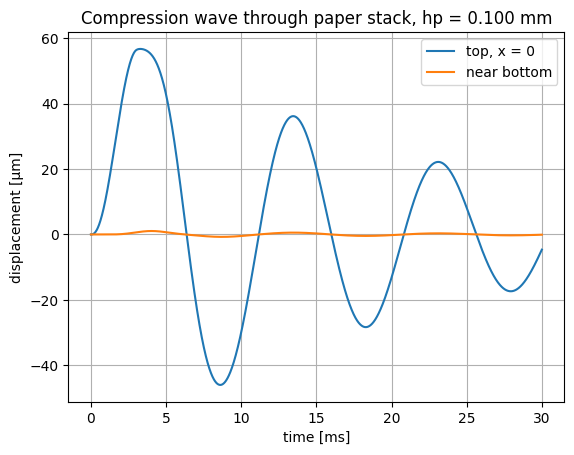

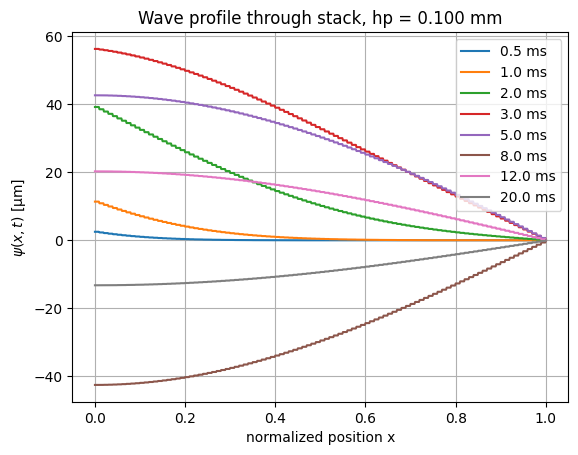

WindowsPath('outputs/paper_lines_hp_0.100mm.gif')

In [13]:
result_010 = simulate_paper_stack_wave(hp=0.10e-3)
print_summary(result_010)

save_wave_plots(result_010)
save_wave_line_animation(result_010)

# Slow one, run only when needed
save_paper_lines_animation(result_010, motion_scale=20)